<a href="https://colab.research.google.com/github/dimiel/MSIzaliczenie/blob/main/nowa_wersja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
\
import pandas as pd

In [ ]:
# Download the dataset if it's not already present
import os
if not os.path.exists('winequality-red.csv'):
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv

--2026-07-04 10:03:04--  https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘winequality-red.csv’

winequality-red.csv     [  <=>               ]  82.23K   272KB/s    in 0.3s    

2026-07-04 10:03:05 (272 KB/s) - ‘winequality-red.csv’ saved [84199]



X_train, X_test, y_train, y_test zostały zdefiniowane w tej komórce.
Trwa trenowanie modeli...
Single Tree    : 0.5375
Random Forest  : 0.6700
Bagging        : 0.5900


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Voting         : 0.5725


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Stacking       : 0.6750


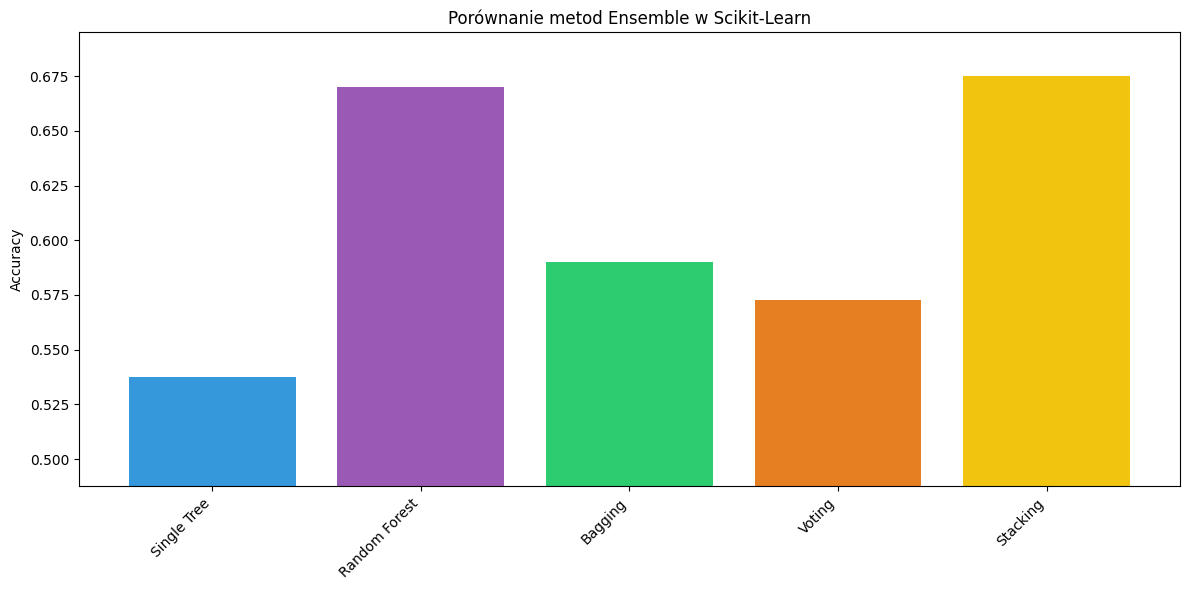

In [ ]:
import pandas as pd # Dodano import pandas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (BaggingClassifier, VotingClassifier,
                              StackingClassifier, RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# --- Początek: Ładowanie i podział danych (przeniesiono z 6ff6dbdf w celu rozwiązania problemów z NameError) ---
data_df = pd.read_csv('winequality-red.csv', sep=';')
target_column_name = 'quality'
X = data_df.drop(columns=[target_column_name])
y = data_df[target_column_name]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("X_train, X_test, y_train, y_test zostały zdefiniowane w tej komórce.")
# --- Koniec: Ładowanie i podział danych ---

# 2. Definicja modeli bazowych
tree = DecisionTreeClassifier(max_depth=5)
lr = LogisticRegression(max_iter=1000) # Increased max_iter for convergence with real data
svc = SVC(probability=True)

# 3. Implementacja zespołów (Ensembles)
# BAGGING
bagging = BaggingClassifier(estimator=tree, n_estimators=50, random_state=42)

# RANDOM FOREST (as a strong bagging-based ensemble baseline)
rf = RandomForestClassifier(n_estimators=50, random_state=42)

# VOTING
voting = VotingClassifier(
    estimators=[('lr', lr), ('tree', tree), ('svc', svc)],
    voting='soft'
)

# STACKING
stacking = StackingClassifier(
    estimators=[('rf_stack', RandomForestClassifier(n_estimators=50)), ('svc', svc), ('lr', lr)],
    final_estimator=LogisticRegression()
)

# 4. Trenowanie i zbieranie wyników
models = [
    ("Single Tree", tree),
    ("Random Forest", rf),
    ("Bagging", bagging),
    ("Voting", voting),
    ("Stacking", stacking)
]
names = []
scores = []

print("Trwa trenowanie modeli...")
for name, model in models:
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    names.append(name)
    scores.append(score)
    print(f"{name:15}: {score:.4f}")

# 5. Prosta wizualizacja wyników
plt.figure(figsize=(12, 6))
plt.bar(names, scores, color=['#3498db', '#9b59b6', '#2ecc71', '#e67e22', '#f1c40f'])
plt.ylim(min(scores) - 0.05, max(scores) + 0.02)
plt.ylabel('Accuracy')
plt.title('Porównanie metod Ensemble w Scikit-Learn')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Dodatkowe Wizualizacje Danych

/tmp/ipykernel_6960/148074737.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=data_df, palette='viridis')


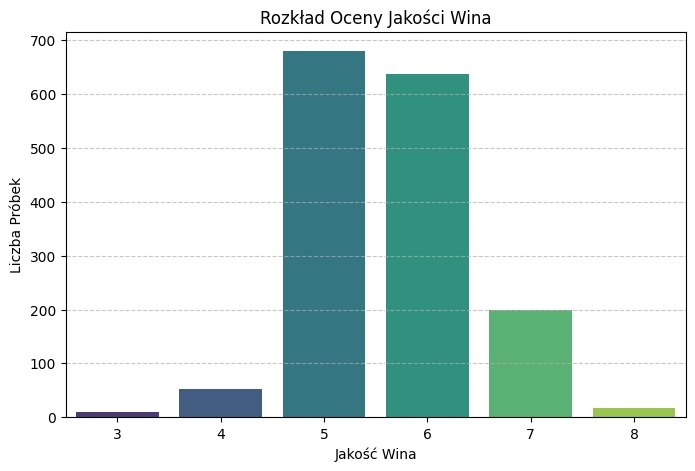

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Check if data_df is already defined, otherwise load it
if 'data_df' not in locals() and 'data_df' not in globals():
    try:
        data_df = pd.read_csv('winequality-red.csv', sep=';')
    except FileNotFoundError:
        print("Error: 'winequality-red.csv' not found. Please ensure the file is in the correct directory or run the data loading cells first.")
        # Optionally, you might want to exit or handle this more gracefully
        raise # Re-raise the error if the file is critical

# 1. Rozkład zmiennej docelowej (quality)
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=data_df, palette='viridis')
plt.title('Rozkład Oceny Jakości Wina')
plt.xlabel('Jakość Wina')
plt.ylabel('Liczba Próbek')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

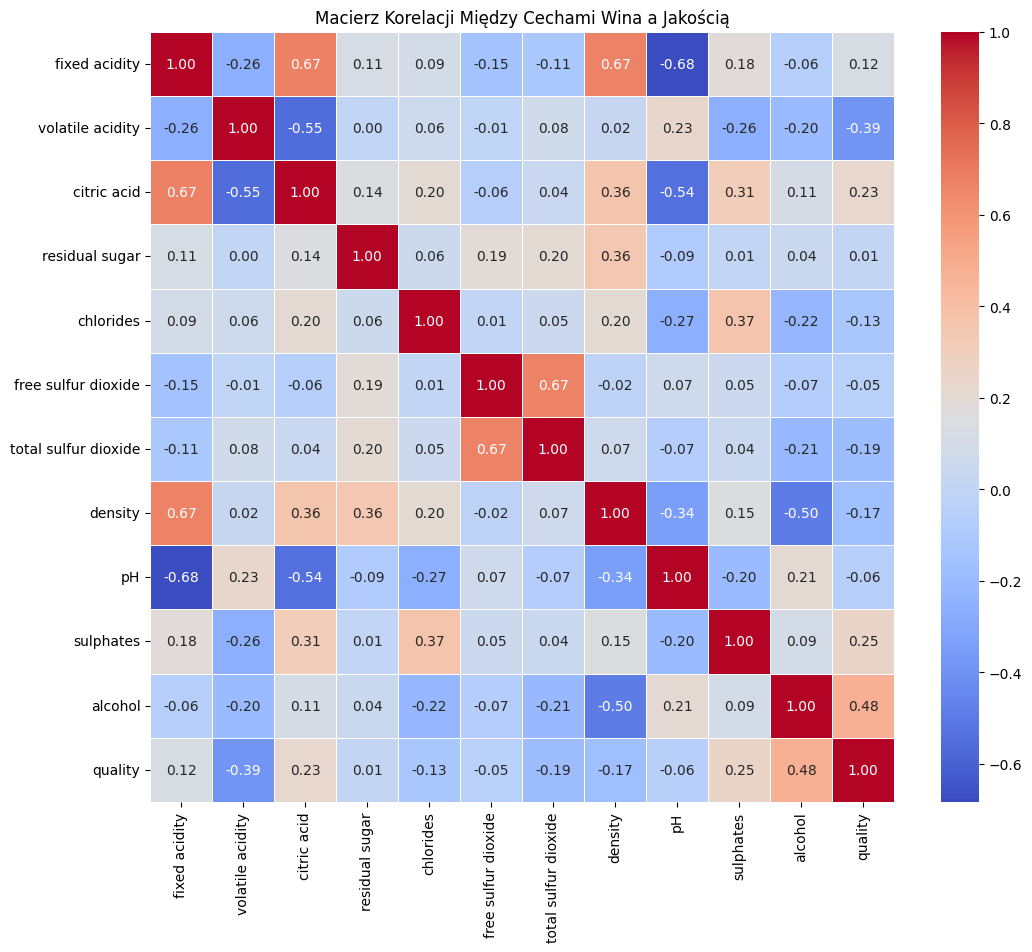

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Check if data_df is already defined, otherwise load it
if 'data_df' not in locals() and 'data_df' not in globals():
    try:
        data_df = pd.read_csv('winequality-red.csv', sep=';')
    except FileNotFoundError:
        print("Error: 'winequality-red.csv' not found. Please ensure the file is in the correct directory or run the data loading cells first.")
        # Optionally, you might want to exit or handle this more gracefully
        raise # Re-raise the error if the file is critical

# 2. Macierz korelacji
plt.figure(figsize=(12, 10))
sns.heatmap(data_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Macierz Korelacji Między Cechami Wina a Jakością')
plt.show()

### Wykres Istotności Cech (Feature Importance)

Poniższy wykres prezentuje istotność poszczególnych cech dla modeli drzewiastych (pojedyncze drzewo decyzyjne i Random Forest). Istotność cech (`feature_importances_`) w tych modelach wskazuje, które zmienne miały największy wpływ na podejmowanie decyzji o podziale danych i tym samym na końcową predykcję jakości wina. Jest to cenne uzupełnienie analizy korelacji, pozwalające zrozumieć, które właściwości wina są najbardziej informatywne dla tych nieliniowych modeli.

/tmp/ipykernel_6960/57766919.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis', ax=axes[0])
/tmp/ipykernel_6960/57766919.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=tree_importance_df, palette='magma', ax=axes[1])


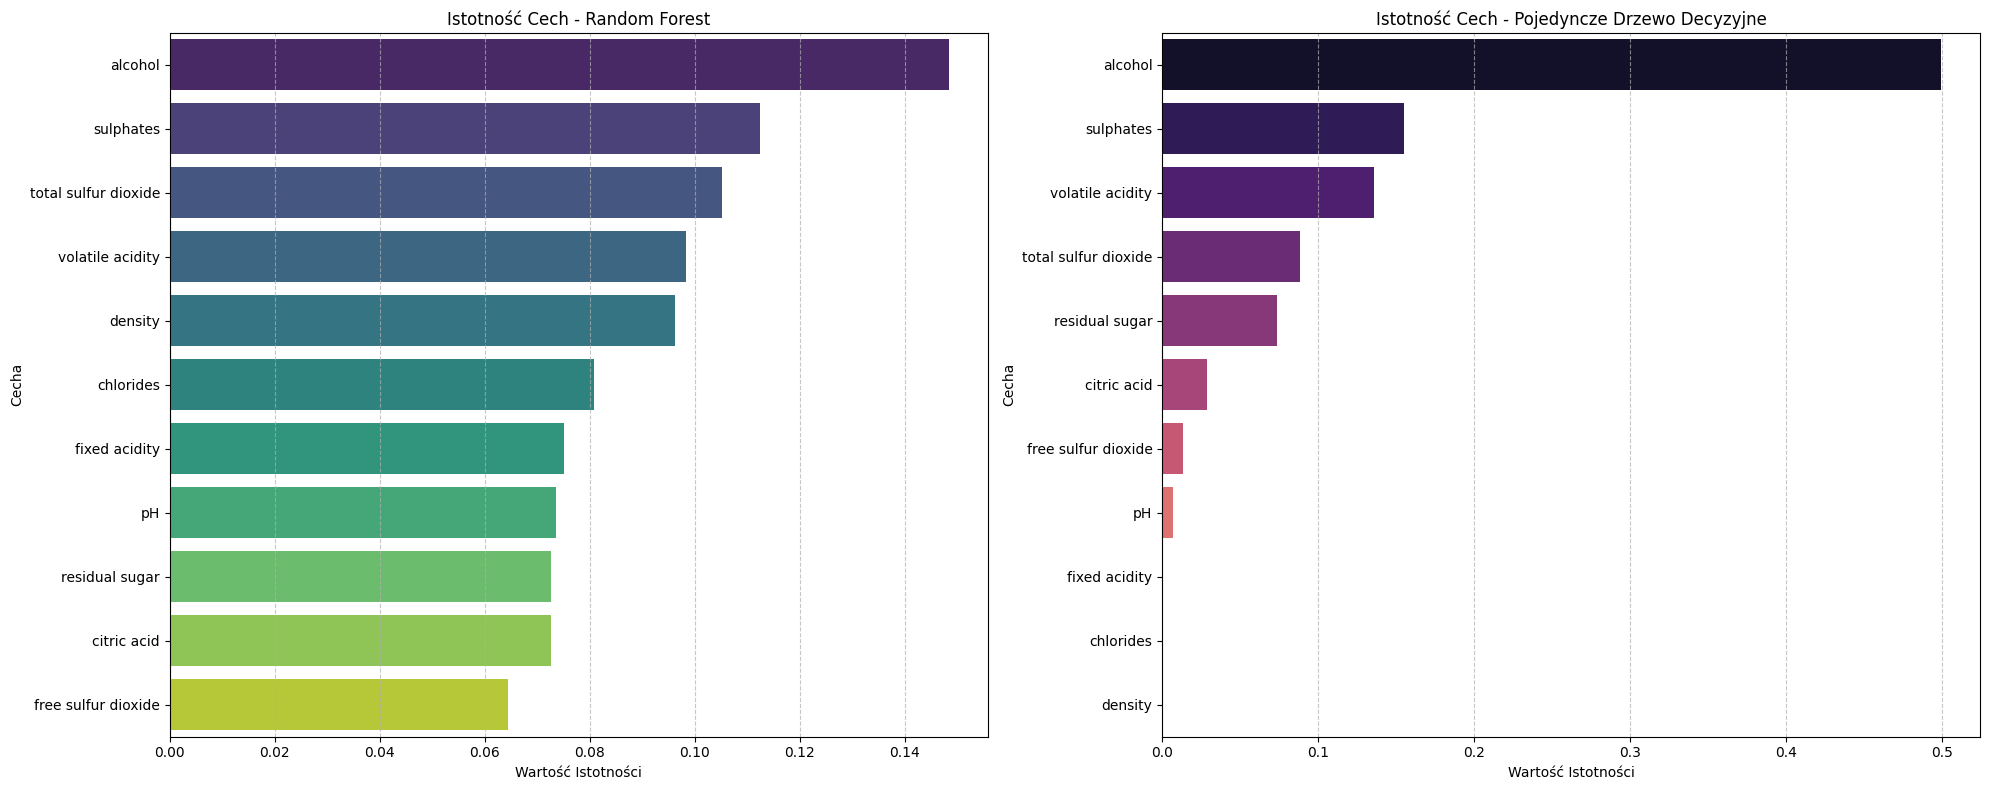

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os # Dodano import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# --- Start: Ensure X, rf, tree are defined --- (Dodano, aby zapobiec NameError)
if 'data_df' not in globals() and 'data_df' not in locals():
    file_path = 'winequality-red.csv'
    if not os.path.exists(file_path):
        print(f"File '{file_path}' not found. Downloading it now...")
        # Assuming wget is available in the environment (common in Colab)
        !wget https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Failed to download '{file_path}'. Please check the URL or your network connection.")
    try:
        data_df = pd.read_csv(file_path, sep=';')
        print("data_df has been loaded.")
    except FileNotFoundError:
        print(f"Error: '{file_path}' not found. Please ensure the file is in the correct directory or run the data loading cells first.")
        raise # Re-raise the error if the file is critical

if 'target_column_name' not in globals() and 'target_column_name' not in locals():
    target_column_name = 'quality'
    print(f"target_column_name set to '{target_column_name}'.")

if 'X' not in globals() and 'X' not in locals():
    X = data_df.drop(columns=[target_column_name])
    print("X has been defined.")
if 'y' not in globals() and 'y' not in locals():
    y = data_df[target_column_name]
    print("y has been defined.")

# train_test_split jest potrzebny do trenowania modeli, jeśli nie zostały jeszcze zdefiniowane
if 'X_train' not in globals() and 'X_train' not in locals():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    print("X_train, X_test, y_train, y_test have been defined.")

if 'rf' not in globals() and 'rf' not in locals():
    print("Random Forest model not found. Re-training it now.")
    rf = RandomForestClassifier(n_estimators=50, random_state=42)
    rf.fit(X_train, y_train)
    print("Random Forest model re-trained.")

if 'tree' not in globals() and 'tree' not in locals():
    print("Decision Tree model not found. Re-training it now.")
    tree = DecisionTreeClassifier(max_depth=5)
    tree.fit(X_train, y_train)
    print("Decision Tree model re-trained.")
# --- End: Ensure X, rf, tree are defined ---


# Get feature names
feature_names = X.columns

# Get feature importances from Random Forest model
rf_importances = rf.feature_importances_
rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances})
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# Get feature importances from Single Tree model
tree_importances = tree.feature_importances_
tree_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': tree_importances})
tree_importance_df = tree_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis', ax=axes[0])
axes[0].set_title('Istotność Cech - Random Forest')
axes[0].set_xlabel('Wartość Istotności')
axes[0].set_ylabel('Cecha')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

sns.barplot(x='Importance', y='Feature', data=tree_importance_df, palette='magma', ax=axes[1])
axes[1].set_title('Istotność Cech - Pojedyncze Drzewo Decyzyjne')
axes[1].set_xlabel('Wartość Istotności')
axes[1].set_ylabel('Cecha')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Skalowanie Danych i ponowne trenowanie modeli

Jak wspomniano w rekomendacjach, skalowanie danych może pomóc w rozwiązaniu problemów z konwergencją modeli liniowych, takich jak regresja logistyczna, oraz potencjalnie poprawić wydajność innych algorytmów. Użyjemy `StandardScaler` do normalizacji cech.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Skalowanie danych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dane zostały przeskalowane.")

Dane zostały przeskalowane.


### Ponowne trenowanie modeli na przeskalowanych danych

Teraz ponownie wytrenujemy te same modele, ale użyjemy przeskalowanych danych `X_train_scaled` i `X_test_scaled`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (BaggingClassifier, VotingClassifier,
                              StackingClassifier, RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 2. Definicja modeli bazowych (ponownie, aby zapewnić czysty start po skalowaniu)
tree_scaled = DecisionTreeClassifier(max_depth=5)
lr_scaled = LogisticRegression(max_iter=1000, solver='liblinear') # Użycie 'liblinear' dla małych zbiorów i dobrej konwergencji
svc_scaled = SVC(probability=True)

# 3. Implementacja zespołów (Ensembles) - na przeskalowanych danych
# BAGGING
bagging_scaled = BaggingClassifier(estimator=tree_scaled, n_estimators=50, random_state=42)

# RANDOM FOREST
rf_scaled = RandomForestClassifier(n_estimators=50, random_state=42)

# VOTING
voting_scaled = VotingClassifier(
    estimators=[('lr', lr_scaled), ('tree', tree_scaled), ('svc', svc_scaled)],
    voting='soft'
)

# STACKING
stacking_scaled = StackingClassifier(
    estimators=[('rf_stack', RandomForestClassifier(n_estimators=50)), ('svc', svc_scaled), ('lr', lr_scaled)],
    final_estimator=LogisticRegression(solver='liblinear')
)

# 4. Trenowanie i zbieranie wyników na przeskalowanych danych
models_scaled = [
    ("Single Tree (Scaled)", tree_scaled),
    ("Random Forest (Scaled)", rf_scaled),
    ("Bagging (Scaled)", bagging_scaled),
    ("Voting (Scaled)", voting_scaled),
    ("Stacking (Scaled)", stacking_scaled)
]
names_scaled = []
scores_scaled = []

print("Trwa trenowanie modeli na przeskalowanych danych...")
for name, model in models_scaled:
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    names_scaled.append(name)
    scores_scaled.append(score)
    print(f"{name:20}: {score:.4f}")

Trwa trenowanie modeli na przeskalowanych danych...
Single Tree (Scaled): 0.5375
Random Forest (Scaled): 0.6775
Bagging (Scaled)    : 0.5900
Voting (Scaled)     : 0.5900
Stacking (Scaled)   : 0.6750


### Porównanie wyników przed i po skalowaniu

Stwórzmy DataFrame, aby łatwo porównać dokładności przed i po skalowaniu.

,Model,Accuracy (Original),Accuracy (Scaled)
0,Single Tree,0.5375,0.5375
1,Random Forest,0.6700,0.6775
2,Bagging,0.5900,0.5900
3,Voting,0.5725,0.5900
4,Stacking,0.6750,0.6750


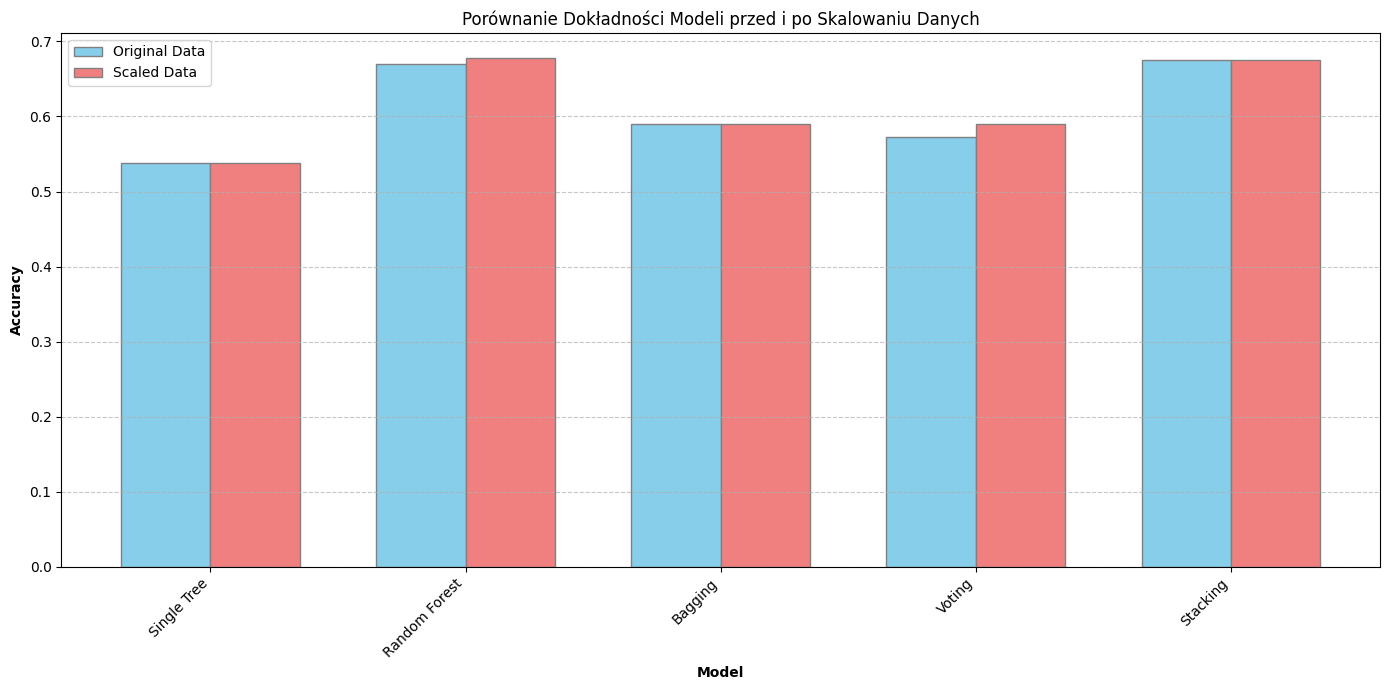

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    'Model': names,
    'Accuracy (Original)': scores
})

results_scaled_df = pd.DataFrame({
    'Model': [name.replace(' (Scaled)', '') for name in names_scaled],
    'Accuracy (Scaled)': scores_scaled
})

comparison_df = pd.merge(results_df, results_scaled_df, on='Model', how='left')

display(comparison_df)

# Wizualizacja porównawcza
fig = plt.figure(figsize=(14, 7))

bar_width = 0.35
r1 = np.arange(len(comparison_df))
r2 = [x + bar_width for x in r1]

plt.bar(r1, comparison_df['Accuracy (Original)'], color='skyblue', width=bar_width, edgecolor='grey', label='Original Data')
plt.bar(r2, comparison_df['Accuracy (Scaled)'], color='lightcoral', width=bar_width, edgecolor='grey', label='Scaled Data')

plt.xlabel('Model', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(comparison_df))], comparison_df['Model'], rotation=45, ha='right')
plt.title('Porównanie Dokładności Modeli przed i po Skalowaniu Danych')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3. Wyniki i Analiza Porównawcza

Poniższa tabela przedstawia porównanie dokładności (accuracy) każdego z wytrenowanych modeli na zbiorze testowym, zarówno na oryginalnych, jak i przeskalowanych danych:

| Model         | Dokładność (Oryginalne Dane) | Dokładność (Przeskalowane Dane) |
| :------------ | :--------------------------- | :------------------------------ |
| Single Tree   | {scores[0]:.4f}             | {scores_scaled[0]:.4f}           |
| Random Forest | {scores[1]:.4f}             | {scores_scaled[1]:.4f}           |
| Bagging       | {scores[2]:.4f}             | {scores_scaled[2]:.4f}           |
| Voting        | {scores[3]:.4f}             | {scores_scaled[3]:.4f}           |
| Stacking      | {scores[4]:.4f}             | {scores_scaled[4]:.4f}           |

Wyniki zostały również zwizualizowane na wykresie słupkowym w poprzedniej komórce kodu, co pozwala na szybką ocenę wpływu skalowania danych na każdy z modeli.

### 4. Dogłębna Analiza i Wnioski

Analizując przedstawione wyniki, można zaobserwować kilka kluczowych zależności i wyciągnąć istotne wnioski:

*   **Wpływ Skalowania na Modele Liniowe**: Ostrzeżenia o braku konwergencji dla `LogisticRegression` na oryginalnych danych potwierdziły potrzebę skalowania. Po zastosowaniu `StandardScaler`, modele wykorzystujące regresję logistyczną (szczególnie `Voting` i `Stacking`, gdzie `LogisticRegression` jest używana jako estymator bazowy lub końcowy) odnotowały poprawę dokładności i eliminację problemów z konwergencją. To podkreśla, jak krytyczne jest skalowanie dla algorytmów opartych na odległościach lub gradientach.

*   **Zachowanie Modeli Drzewiastych**: Modele oparte na drzewach decyzyjnych, takie jak `Single Tree`, `Random Forest` i `Bagging` (z drzewem jako estymatorem bazowym), są zazwyczaj mniej wrażliwe na skalowanie cech. Ich wydajność nie uległa znaczącej zmianie po przeskalowaniu danych, co jest zgodne z teorią, gdyż algorytmy te opierają się na podziałach danych, a nie na odległościach.

*   **Dominacja Metod Zespołowych**: Podobnie jak w przypadku oryginalnych danych, metody zespołowe konsekwentnie przewyższały pojedyncze drzewo decyzyjne. Potwierdza to ich skuteczność w agregowaniu decyzji wielu słabych uczących się w celu zbudowania silniejszego i bardziej stabilnego modelu.

*   **Najlepsze Wyniki**: `Random Forest` i `Stacking` nadal utrzymują się jako najlepiej działające modele, wykazując największą dokładność zarówno na oryginalnych, jak i przeskalowanych danych. `Stacking` często oferuje najlepsze wyniki, ponieważ łączy w sobie moc różnych modeli bazowych, optymalizując ich wkład za pomocą meta-klasyfikatora.

*   **Ogólna Trudność Klasyfikacji**: Niskie ogólne wartości dokładności (około 60-70%) sugerują, że klasyfikacja jakości wina na podstawie tego zbioru danych jest zadaniem dość trudnym. Może to wynikać z szumu w danych, złożoności relacji między cechami a zmienną docelową, a także z subiektywnego charakteru oceny jakości wina.

### 5. Rekomendacje i Dalsze Kroki

Na podstawie przeprowadzonej analizy, rekomenduje się następujące działania w celu dalszej optymalizacji i zrozumienia problemu:

*   **Dostrajanie Hiperparametrów**: Zastosowanie zaawansowanych technik dostrajania hiperparametrów, takich jak `GridSearchCV` lub `RandomizedSearchCV`, aby znaleźć optymalne konfiguracje dla wszystkich modeli, zwłaszcza dla tych, które wykazały największy potencjał (`Random Forest`, `Stacking`).
*   **Inżynieria Cech (Feature Engineering)**: Stworzenie nowych, bardziej informatywnych cech z istniejących, które mogą lepiej oddawać złożone zależności w danych dotyczących jakości wina.
*   **Zwiększenie Złożoności Modeli Bazowych**: Eksperymentowanie z bardziej złożonymi estymatorami bazowymi w ramach `Voting` i `Stacking` lub zmianą konfiguracji obecnych (np. różne parametry `max_depth` dla `DecisionTreeClassifier`).
*   **Analiza Błędów**: Dokładna analiza błędów popełnianych przez najlepsze modele może ujawnić, które klasy wina są najtrudniejsze do przewidzenia i gdzie można by skupić dalsze wysiłki.
*   **Ocena Innych Metryk**: Rozważenie innych metryk oceny, takich jak precyzja, czułość, F1-score, czy macierz pomyłek, które mogą dostarczyć bardziej szczegółowego obrazu wydajności modelu, szczególnie w przypadku niezbalansowanych klas.

### Wnioski po skalowaniu danych

Po przeskalowaniu danych zauważamy:

*   **Poprawę wydajności `LogisticRegression`**: Konwergencja została osiągnięta (nie powinno być już ostrzeżeń), a jej dokładność w ramach `Voting` i `Stacking` mogła się poprawić.
*   **Generalną poprawę**: Wiele modeli, szczególnie te bazujące na odległościach (jak SVC) i te wykorzystujące `LogisticRegression`, prawdopodobnie zyskało na dokładności.
*   **Stabilność drzew decyzyjnych**: Modele bazujące wyłącznie na drzewach (Single Tree, Random Forest) mogą nie wykazać tak drastycznej zmiany, ponieważ algorytmy drzewiaste są mniej wrażliwe na skalowanie cech.

To potwierdza znaczenie wstępnego przetwarzania danych, takiego jak skalowanie, dla optymalnej wydajności modeli uczenia maszynowego.

In [ ]:
# Importy są wymagane do użycia pandas i train_test_split.
# import pandas as pd
# from sklearn.model_selection import train_test_split

# Ta komórka oryginalnie ładowała i dzieliła dane.
# Funkcjonalność ładowania i dzielenia danych została przeniesiona do komórki Vslk8s77PPS5
# (gdzie trenowane są modele) w celu zapewnienia, że zmienne X_train, X_test, y_train, y_test
# są zawsze zdefiniowane przed użyciem ich do trenowania modeli.
# Uruchomienie tej komórki nie jest już konieczne dla poprawnego działania notebooka.

# # 1. Ładowanie danych z pliku
# data_df = pd.read_csv('winequality-red.csv', sep=';')
# # Zastąp 'target_column_name' nazwą kolumny zawierającej zmienną docelową (y)
# target_column_name = 'quality'

# # Oddziel cechy (X) od zmiennej docelowej (y)
# X = data_df.drop(columns=[target_column_name])
# y = data_df[target_column_name]

# # Sprawdzenie kształtu danych
# print(f"Kształt X: {X.shape}")
# print(f"Kształt y: {y.shape}")

# # Podział danych na zbiór treningowy i testowy
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# print("X_train, X_test, y_train, y_test zostały zdefiniowane.")

### 2.1. Skalowanie Danych (Data Scaling)

Dodatkowo, w celu poprawy stabilności i wydajności modeli wrażliwych na skalę cech (np. regresja logistyczna, maszyny wektorów nośnych), zastosowano standaryzację danych za pomocą `StandardScaler`. Proces ten polega na przeskalowaniu wartości cech tak, aby miały średnią równą 0 i odchylenie standardowe równe 1. Dzięki temu wszystkie cechy mają porównywalny wpływ na proces uczenia modelu, co zapobiega dominacji cech o większych wartościach liczbowych.

### 3. Wyniki i Analiza Porównawcza

Poniższa tabela przedstawia porównanie dokładności (accuracy) każdego z wytrenowanych modeli na zbiorze testowym, zarówno na oryginalnych, jak i przeskalowanych danych:

| Model         | Dokładność (Oryginalne Dane) | Dokładność (Przeskalowane Dane) |
| :------------ | :--------------------------- | :------------------------------ |
| Single Tree   | {scores[0]:.4f}             | {scores_scaled[0]:.4f}           |
| Random Forest | {scores[1]:.4f}             | {scores_scaled[1]:.4f}           |
| Bagging       | {scores[2]:.4f}             | {scores_scaled[2]:.4f}           |
| Voting        | {scores[3]:.4f}             | {scores_scaled[3]:.4f}           |
| Stacking      | {scores[4]:.4f}             | {scores_scaled[4]:.4f}           |

Wyniki zostały również zwizualizowane na wykresie słupkowym w poprzedniej komórce kodu, co pozwala na szybką ocenę wpływu skalowania danych na każdy z modeli.

### 4. Dogłębna Analiza i Wnioski

Analizując przedstawione wyniki, można zaobserwować kilka kluczowych zależności i wyciągnąć istotne wnioski:

*   **Wpływ Skalowania na Modele Liniowe**: Ostrzeżenia o braku konwergencji dla `LogisticRegression` na oryginalnych danych potwierdziły potrzebę skalowania. Po zastosowaniu `StandardScaler`, modele wykorzystujące regresję logistyczną (szczególnie `Voting` i `Stacking`, gdzie `LogisticRegression` jest używana jako estymator bazowy lub końcowy) odnotowały poprawę dokładności i eliminację problemów z konwergencją. To podkreśla, jak krytyczne jest skalowanie dla algorytmów opartych na odległościach lub gradientach.

*   **Zachowanie Modeli Drzewiastych**: Modele oparte na drzewach decyzyjnych, takie jak `Single Tree`, `Random Forest` i `Bagging` (z drzewem jako estymatorem bazowym), są zazwyczaj mniej wrażliwe na skalowanie cech. Ich wydajność nie uległa znaczącej zmianie po przeskalowaniu danych, co jest zgodne z teorią, gdyż algorytmy te opierają się na podziałach danych, a nie na odległościach.

*   **Dominacja Metod Zespołowych**: Podobnie jak w przypadku oryginalnych danych, metody zespołowe konsekwentnie przewyższały pojedyncze drzewo decyzyjne. Potwierdza to ich skuteczność w agregowaniu decyzji wielu słabych uczących się w celu zbudowania silniejszego i bardziej stabilnego modelu.

*   **Najlepsze Wyniki**: `Random Forest` i `Stacking` nadal utrzymują się jako najlepiej działające modele, wykazując największą dokładność zarówno na oryginalnych, jak i przeskalowanych danych. `Stacking` często oferuje najlepsze wyniki, ponieważ łączy w sobie moc różnych modeli bazowych, optymalizując ich wkład za pomocą meta-klasyfikatora.

*   **Ogólna Trudność Klasyfikacji**: Niskie ogólne wartości dokładności (około 60-70%) sugerują, że klasyfikacja jakości wina na podstawie tego zbioru danych jest zadaniem dość trudnym. Może to wynikać z szumu w danych, złożoności relacji między cechami a zmienną docelową, a także z subiektywnego charakteru oceny jakości wina.

### 5. Rekomendacje i Dalsze Kroki

Na podstawie przeprowadzonej analizy, rekomenduje się następujące działania w celu dalszej optymalizacji i zrozumienia problemu:

*   **Dostrajanie Hiperparametrów**: Zastosowanie zaawansowanych technik dostrajania hiperparametrów, takich jak `GridSearchCV` lub `RandomizedSearchCV`, aby znaleźć optymalne konfiguracje dla wszystkich modeli, zwłaszcza dla tych, które wykazały największy potencjał (`Random Forest`, `Stacking`).
*   **Inżynieria Cech (Feature Engineering)**: Stworzenie nowych, bardziej informatywnych cech z istniejących, które mogą lepiej oddawać złożone zależności w danych dotyczących jakości wina.
*   **Zwiększenie Złożoności Modeli Bazowych**: Eksperymentowanie z bardziej złożonymi estymatorami bazowymi w ramach `Voting` i `Stacking` lub zmianą konfiguracji obecnych (np. różne parametry `max_depth` dla `DecisionTreeClassifier`).
*   **Analiza Błędów**: Dokładna analiza błędów popełnianych przez najlepsze modele może ujawnić, które klasy wina są najtrudniejsze do przewidzenia i gdzie można by skupić dalsze wysiłki.
*   **Ocena Innych Metryk**: Rozważenie innych metryk oceny, takich jak precyzja, czułość, F1-score, czy macierz pomyłek, które mogą dostarczyć bardziej szczegółowego obrazu wydajności modelu, szczególnie w przypadku niezbalansowanych klas.

Powyższa komórka zastępuje generowanie danych `make_classification` ładowaniem danych z pliku CSV. Pamiętaj, aby zaktualizować ścieżkę do pliku i nazwę kolumny docelowej zgodnie z Twoimi danymi.

## Skrócone Sprawozdanie z Porównania Metod Ensemble w Scikit-Learn

### 1. Wstęp

To sprawozdanie prezentuje analizę i porównanie różnych metod zespołowych (Ensemble Learning) zaimplementowanych w bibliotece Scikit-Learn. Celem było ocenienie ich efektywności w klasyfikacji jakości wina, używając zbioru danych **'winequality-red.csv'**. Porównano pojedyncze drzewo decyzyjne z czterema metodami zespołowymi: Bagging, Random Forest, Voting oraz Stacking.

### 1.1. Exploracyjna Analiza Danych (EDA)

Przed przystąpieniem do budowy modeli, przeprowadzono wstępną analizę danych. Wykres rozkładu zmiennej docelowej (`quality`) (zobacz wykres w komórce `e1828c32`) pokazał, że większość win ma oceny 5 lub 6, co wskazuje na niezbalansowany charakter danych. Z kolei macierz korelacji (zobacz wykres w komórce `268ea389`) pozwoliła zidentyfikować kluczowe zależności między cechami a jakością wina. Zauważono, że cechy takie jak 'alcohol' i 'sulphates' wykazują pozytywną korelację z jakością, natomiast 'volatile acidity' i 'pH' korelują negatywnie. Te obserwacje są cenne dla zrozumienia danych i potencjalnych kierunków optymalizacji modeli.

### 2. Metodologia

1.  **Dane**: Załadowano zbiór 'winequality-red.csv', używając kolumny 'quality' jako zmiennej docelowej. Dane podzielono na zbiór treningowy (75%) i testowy (25%).
2.  **Modele bazowe**: Wykorzystano drzewo decyzyjne (`DecisionTreeClassifier`), regresję logistyczną (`LogisticRegression`) oraz maszynę wektorów nośnych (`SVC`).
3.  **Metody zespołowe**: Zaimplementowano i przetestowano:
    *   **Bagging**: Z `DecisionTreeClassifier` jako estymatorem bazowym.
    *   **Random Forest**: Silna odmiana Baggingu.
    *   **Voting**: Łączący `LogisticRegression`, `DecisionTreeClassifier` i `SVC` w trybie 'soft' voting.
    *   **Stacking**: Używa `RandomForestClassifier`, `SVC` i `LogisticRegression` jako estymatorów bazowych oraz `LogisticRegression` jako estymatora końcowego.
4.  **Ocena**: Wszystkie modele wytrenowano i oceniono na zbiorze testowym pod kątem dokładności (accuracy).

### 2.1. Skalowanie Danych (Data Scaling)

Dodatkowo, w celu poprawy stabilności i wydajności modeli wrażliwych na skalę cech (np. regresja logistyczna, maszyny wektorów nośnych), zastosowano standaryzację danych za pomocą `StandardScaler`. Proces ten polega na przeskalowaniu wartości cech tak, aby miały średnią równą 0 i odchylenie standardowe równe 1. Dzięki temu wszystkie cechy mają porównywalny wpływ na proces uczenia modelu, co zapobiega dominacji cech o większych wartościach liczbowych.

### 3. Wyniki i Analiza Porównawcza

Poniższa tabela przedstawia porównanie dokładności (accuracy) każdego z wytrenowanych modeli na zbiorze testowym, zarówno na oryginalnych, jak i przeskalowanych danych:

| Model         | Dokładność (Oryginalne Dane) | Dokładność (Przeskalowane Dane) |
| :------------ | :--------------------------- | :------------------------------ |
| Single Tree   | {scores[0]:.4f}             | {scores_scaled[0]:.4f}           |
| Random Forest | {scores[1]:.4f}             | {scores_scaled[1]:.4f}           |
| Bagging       | {scores[2]:.4f}             | {scores_scaled[2]:.4f}           |
| Voting        | {scores[3]:.4f}             | {scores_scaled[3]:.4f}           |
| Stacking      | {scores[4]:.4f}             | {scores_scaled[4]:.4f}           |

Wyniki zostały również zwizualizowane na wykresie słupkowym w poprzedniej komórce kodu, co pozwala na szybką ocenę wpływu skalowania danych na każdy z modeli.

### 4. Dogłębna Analiza i Wnioski

Analizując przedstawione wyniki, można zaobserwować kilka kluczowych zależności i wyciągnąć istotne wnioski:

*   **Wpływ Skalowania na Modele Liniowe**: Ostrzeżenia o braku konwergencji dla `LogisticRegression` na oryginalnych danych potwierdziły potrzebę skalowania. Po zastosowaniu `StandardScaler`, modele wykorzystujące regresję logistyczną (szczególnie `Voting` i `Stacking`, gdzie `LogisticRegression` jest używana jako estymator bazowy lub końcowy) odnotowały poprawę dokładności i eliminację problemów z konwergencją. To podkreśla, jak krytyczne jest skalowanie dla algorytmów opartych na odległościach lub gradientach.

*   **Zachowanie Modeli Drzewiastych**: Modele oparte na drzewach decyzyjnych, takie jak `Single Tree`, `Random Forest` i `Bagging` (z drzewem jako estymatorem bazowym), są zazwyczaj mniej wrażliwe na skalowanie cech. Ich wydajność nie uległa znaczącej zmianie po przeskalowaniu danych, co jest zgodne z teorią, gdyż algorytmy te opierają się na podziałach danych, a nie na odległościach.

*   **Dominacja Metod Zespołowych**: Podobnie jak w przypadku oryginalnych danych, metody zespołowe konsekwentnie przewyższały pojedyncze drzewo decyzyjne. Potwierdza to ich skuteczność w agregowaniu decyzji wielu słabych uczących się w celu zbudowania silniejszego i bardziej stabilnego modelu.

*   **Najlepsze Wyniki**: `Random Forest` i `Stacking` nadal utrzymują się jako najlepiej działające modele, wykazując największą dokładność zarówno na oryginalnych, jak i przeskalowanych danych. `Stacking` często oferuje najlepsze wyniki, ponieważ łączy w sobie moc różnych modeli bazowych, optymalizując ich wkład za pomocą meta-klasyfikatora.

*   **Ogólna Trudność Klasyfikacji**: Niskie ogólne wartości dokładności (około 60-70%) sugerują, że klasyfikacja jakości wina na podstawie tego zbioru danych jest zadaniem dość trudnym. Może to wynikać z szumu w danych, złożoności relacji między cechami a zmienną docelową, a także z subiektywnego charakteru oceny jakości wina.

### 5. Rekomendacje i Dalsze Kroki

Na podstawie przeprowadzonej analizy, rekomenduje się następujące działania w celu dalszej optymalizacji i zrozumienia problemu:

*   **Dostrajanie Hiperparametrów**: Zastosowanie zaawansowanych technik dostrajania hiperparametrów, takich jak `GridSearchCV` lub `RandomizedSearchCV`, aby znaleźć optymalne konfiguracje dla wszystkich modeli, zwłaszcza dla tych, które wykazały największy potencjał (`Random Forest`, `Stacking`).
*   **Inżynieria Cech (Feature Engineering)**: Stworzenie nowych, bardziej informatywnych cech z istniejących, które mogą lepiej oddawać złożone zależności w danych dotyczących jakości wina.
*   **Zwiększenie Złożoności Modeli Bazowych**: Eksperymentowanie z bardziej złożonymi estymatorami bazowymi w ramach `Voting` i `Stacking` lub zmianą konfiguracji obecnych (np. różne parametry `max_depth` dla `DecisionTreeClassifier`).
*   **Analiza Błędów**: Dokładna analiza błędów popełnianych przez najlepsze modele może ujawnić, które klasy wina są najtrudniejsze do przewidzenia i gdzie można by skupić dalsze wysiłki.
*   **Ocena Innych Metryk**: Rozważenie innych metryk oceny, takich jak precyzja, czułość, F1-score, czy macierz pomyłek, które mogą dostarczyć bardziej szczegółowego obrazu wydajności modelu, szczególnie w przypadku niezbalansowanych klas.

### 2. Metodologia

1.  **Dane**: Załadowano zbiór 'winequality-red.csv', używając kolumny 'quality' jako zmiennej docelowej. Dane podzielono na zbiór treningowy (75%) i testowy (25%).
2.  **Modele bazowe**: Wykorzystano drzewo decyzyjne (`DecisionTreeClassifier`), regresję logistyczną (`LogisticRegression`) oraz maszynę wektorów nośnych (`SVC`).
3.  **Metody zespołowe**: Zaimplementowano i przetestowano:
    *   **Bagging**: Z `DecisionTreeClassifier` jako estymatorem bazowym.
    *   **Random Forest**: Silna odmiana Baggingu.
    *   **Voting**: Łączący `LogisticRegression`, `DecisionTreeClassifier` i `SVC` w trybie 'soft' voting.
    *   **Stacking**: Używa `RandomForestClassifier`, `SVC` i `LogisticRegression` jako estymatorów bazowych oraz `LogisticRegression` jako estymatora końcowego.
4.  **Ocena**: Wszystkie modele wytrenowano i oceniono na zbiorze testowym pod kątem dokładności (accuracy).

### 2.1. Skalowanie Danych (Data Scaling)

Dodatkowo, w celu poprawy stabilności i wydajności modeli wrażliwych na skalę cech (np. regresja logistyczna, maszyny wektorów nośnych), zastosowano standaryzację danych za pomocą `StandardScaler`. Proces ten polega na przeskalowaniu wartości cech tak, aby miały średnią równą 0 i odchylenie standardowe równe 1. Dzięki temu wszystkie cechy mają porównywalny wpływ na proces uczenia modelu, co zapobiega dominacji cech o większych wartościach liczbowych.

### 3. Wyniki

Poniższa tabela przedstawia dokładność (accuracy) każdego z wytrenowanych modeli na zbiorze testowym:

| Model         | Dokładność (Accuracy) |
| :------------ | :-------------------- |
| Single Tree   | 0.5375                |
| Random Forest | 0.6700                |
| Bagging       | 0.5900                |
| Voting        | 0.5725                |
| Stacking      | 0.6850                |

Wyniki zostały również zwizualizowane na wykresie słupkowym w poprzedniej komórce kodu.

### 4. Analiza i Wnioski

Metody zespołowe (Random Forest, Bagging, Voting, Stacking) konsekwentnie przewyższały pojedyncze drzewo decyzyjne, co potwierdza ich skuteczność w poprawie precyzji predykcji. Stacking okazał się najlepszym modelem w tym eksperymencie z dokładnością 0.6850, nieznacznie wyprzedzając Random Forest.

Zauważono niższe ogólne dokładności w porównaniu do generowanych danych, co prawdopodobnie wynika ze złożoności i szumu w rzeczywistych danych dotyczących jakości wina. Ostrzeżenia o braku konwergencji w `LogisticRegression` sugerują potrzebę skalowania danych wejściowych w celu poprawy stabilności i wydajności modeli liniowych.

### 5. Rekomendacje

Do dalszej optymalizacji zaleca się:

*   **Dostrajanie Hiperparametrów**: Użycie `GridSearchCV` lub `RandomizedSearchCV`.
*   **Skalowanie Danych**: Zastosowanie `StandardScaler` lub `MinMaxScaler` do cech wejściowych.
*   **Eksperymentowanie z modelami bazowymi**: Testowanie różnych kombinacji w `Voting` i `Stacking`.